In [7]:
import numpy as np
import matplotlib.pyplot as plt

# import jax
# import jax.numpy as jnp
# from jax.config import config

import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, ScalarFormatter
import seaborn as sns
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, ScalarFormatter
plt.rcParams['text.usetex'] = True

# !pip install colossus

# from colossus.cosmology import cosmology
# from colossus.lss import peaks
# cosmology.setCosmology('planck15')

from astropy.cosmology import Planck15 as cosmo
from astropy import units as u
import astropy.constants as c
import h5py
import os
import warnings

# !pip install gplearn

from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function
from gplearn.fitness import make_fitness
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sympy import *
from sklearn.utils.random import check_random_state
import graphviz
import time

# !sudo apt-get install texlive-fonts-recommended texlive-fonts-extra
# !sudo apt-get install dvipng
# !sudo apt-get install cm-super

In [6]:
!pip install graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
!pip install colossus

In [ ]:
!pip uninstall jax jaxlib

Found existing installation: jax 0.4.28
Uninstalling jax-0.4.28:
  Would remove:
    /Users/demiant/opt/anaconda3/lib/python3.9/site-packages/jax-0.4.28.dist-info/*
    /Users/demiant/opt/anaconda3/lib/python3.9/site-packages/jax/*
Proceed (Y/n)? 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
converter = {
    'add': lambda x, y : x + y,
    'sub': lambda x, y : x - y,
    'mul': lambda x, y : x*y,
    'div': lambda x, y : x/y,
    'sqrt': lambda x : x**0.5,
    'log': lambda x : log(x),
    'abs': lambda x : abs(x),
    'neg': lambda x : -x,
    'inv': lambda x : 1/x,
    'max': lambda x, y : max(x, y),
    'min': lambda x, y : min(x, y),
    'sin': lambda x : sin(x),
    'cos': lambda x : cos(x),
    'pow': lambda x, y : x**y,
}

In [9]:
def virial_values(M, z, cosmo, mdef = 'vir', quantity='pressure', mu = 0.59): #change quantity from pressure to radius, virial_values for radius
    '''Calculate the virial/normalized values for different quantities of halos
    according to Lau+2015
    Parameters:
       M: halo mass in Msun unit, h=1
       z: redshift
       cosmo: astropy cosmology object
       mdef: mass definition, vir, xxc or xxm
       quantity: virial quantity to calculate,
       radius, pressure, temperature, velocity
       mu: mean particle weigh
    Return:
       virial quantity. Can use .to('xx') to convert to desired units.
       Default units are radius(kpc), P(keV/cm3), T(keV), v(km/s)
    '''
    rho_crit = cosmo.critical_density(z)
    if mdef == 'vir':
        x = cosmo.Om(z) - 1
        delta = 18 * np.pi**2 + 82.0 * x - 39.0 * x**2
        rho = delta*rho_crit
    elif mdef[-1] == 'c':
        delta = int(mdef[:-1])
        rho = delta*rho_crit
    elif mdef[-1] == 'm':
        delta = int(mdef[:-1])
        rho = delta*rho_crit*cosmo.Om(z)
    else:
        raise ValueError("Unsupported mdef")
    fb = cosmo.Ob0/cosmo.Om0
    M = M*u.Msun
    R = ((3*M/(np.pi*4*rho))**(1./3)).to('kpc')
    if quantity=='radius':
        return R
    elif quantity=='pressure':
        return (fb*rho*c.G*M/(2*R)).to('keV/cm3')
    elif quantity=='temperature':
        return (c.G*M*mu*c.m_p/(2*R)).to('keV')
    elif quantity=='velocity':
        return np.sqrt(c.G*M/R).to('km/s')
    else:
        raise ValueError("Unsupported quantity")

def get_halo_keys(my_file):
    """
    Return all group keys in a map analysis file

    Arguments:
      -my_file : The file from which to extract keys
    """

    f  = h5py.File(my_file, 'r')
    fk = list(f.keys())
    f.close()
    fk.sort()
    return fk

def attribute_read(my_file, keys, att):
    """
    Read an attribute for all keys from a file

    Arguments:
      -my_file : The file from which to read
      -keys    : File keys to examine
      -att     : Attribute to read for each key

    Returns:
      -data : A 1D array containing all attributes read
    """

    f    = h5py.File(my_file, 'r')
    data = np.zeros(len(keys))
    for j in range(0, len(keys), 1):
        data[j] = f[keys[j]].attrs[att]
    f.close()
    return data

def dataset_read(my_file, keys, dset):
    """
    Read an attribute for all keys from a file

    Arguments:
      -my_file : The file from which to read
      -keys    : File keys to examine
      -dset    : Dataset to read for each key

    Returns:
      -data : A 2D array where each row is a dataset
    """

    f     = h5py.File(my_file, 'r')
    shape = f[keys[0]][dset].shape
    if len(shape) == 1:
        data  = np.zeros((len(keys), shape[0]), dtype=np.float64)
    elif len(shape) == 2:
        data  = np.zeros((len(keys), shape[0], shape[1]), dtype=np.float64)

    for j in range(0, len(keys), 1): data[j] = f[keys[j]][dset][:]
    f.close()
    del shape
    return data

In [15]:
def tng_profiles_all(tng_data_file):
    filename = tng_data_file
    halo_ids = np.array(get_halo_keys(filename))
    mass = attribute_read(filename, halo_ids, 'M200_Msun')
    mass_select_mask = (mass>0) & (mass>0) # taking all masses
    mass_select = mass[mass_select_mask]
    return mass_select


def tng_profiles(tng_data_file, log_M0):

    '''
    Input:
        tng_data_file = variable defined as the datafile path
        log(M0) = median mass, ex. 14.0

    Outputs:
        TNG_Qdm: intermediate-major axis (b/c) for DM
        TNG_Qgas: intermediate-major axis (b/c) for gas
        TNG_Sdm: minor-major axis (a/c) for DM
        TNG_Sgas: minor-major axis (a/c) for gas
        TNG_fnth: non-thermal pressure fraction
    '''

    filename = tng_data_file
    if log_M0 >= 14.5:
        lower_mass, higher_mass = (log_M0), (log_M0 + 0.5)
    else:
        lower_mass, higher_mass = (log_M0 - 0.1), (log_M0 + 0.1) # mass bin

    halo_ids = np.array(get_halo_keys(filename))
    mass = attribute_read(filename, halo_ids, 'M200_Msun')
    rad = attribute_read(filename, halo_ids, 'R200_Mpc') # do this div by virial_values
    rvir = attribute_read(filename, halo_ids, 'Rvir_Mpc')
    conc = attribute_read(filename, halo_ids, 'Cvir')
    # macc = attribute_read(filename, halo_ids, 'Macc_200c')

    #mass_select_mask = (mass>10**13.0) & (mass<10**13.2)
    mass_select_mask = (mass>10**lower_mass) & (mass<10**higher_mass) # taking all masses
    halo_ids_select = halo_ids[mass_select_mask] # each halo within the TNG catalog is given a ID
    #print('Number of halos between %s - %s'%(lower_mass, higher_mass),len(halo_ids_select))
    mass_select = mass[mass_select_mask]
    rad_select = rad[mass_select_mask]
    rvir_select = rvir[mass_select_mask]
    conc_select = conc[mass_select_mask]
    # macc_select = macc[mass_select_mask]

    TNGm = dataset_read(filename, halo_ids_select, 'Mgas_Msun')*u.Msun
    Xoff = attribute_read(filename, halo_ids, 'Xoff') # distance between center of mass and minimum gravitational energy
    TNGv = dataset_read(filename, halo_ids_select, 'Volumes_Mpc^3')*u.Mpc**3
    TNGT = dataset_read(filename, halo_ids_select, 'Tmw_keV')*u.keV
    TNGr = dataset_read(filename, halo_ids_select, 'Radii_Mpc')*u.Mpc
    TNGnth = (dataset_read(filename, halo_ids_select, 'Pnth_erg_cm^-3')*u.erg/u.cm**3)/3.

    TNG_Qdm = dataset_read(filename, halo_ids_select, 'Qdm')
    TNG_Qgas = dataset_read(filename, halo_ids_select, 'Qgas')

    TNG_Sdm = dataset_read(filename, halo_ids_select, 'Sdm')
    TNG_Sgas = dataset_read(filename, halo_ids_select, 'Sgas')

    mu = 0.59
    xoff_select = Xoff[mass_select_mask]
    TNGrho = TNGm/TNGv
    TNGPth = (TNGrho*TNGT/(mu*c.m_p))
    TNGPtot = TNGPth + TNGnth
    # TNGPtot_select = TNGPtot[mass_select_mask]
    TNGnr = TNGr/(rad_select[:,None]*u.Mpc)

    # changed mdef=200c to mdef=200m
    TNG_pressure_array = (TNGPth/virial_values(mass_select, 0, cosmo, mdef='200m', quantity='pressure')[:,None]).to('')
    TNG_ptot_array = (TNGPtot/virial_values(mass_select, 0, cosmo, mdef='200m', quantity='pressure')[:,None]).to('')
    TNG_rho_array = (TNGrho/ mu / c.m_p).to('/cm3').value
    TNG_T_array = (TNGT/virial_values(mass_select, 0, cosmo, mdef='200m', quantity='temperature')[:,None]).to('')

    TNG_fnth = 1 - (TNG_pressure_array/TNG_ptot_array)

    return TNGnr[0], TNG_Qdm, TNG_Qgas, TNG_Sdm, TNG_Sgas, TNG_fnth

def TNG_percentiles(tng_data_file, log_M0, percentile):

    _, TNG_Qdm, TNG_Qgas, TNG_Sdm, TNG_Sgas, TNG_fnth, = tng_profiles(tng_data_file, log_M0)

    TNG_Qdm_pct = np.percentile(TNG_Qdm, percentile, axis=0)
    TNG_Qgas_pct = np.percentile(TNG_Qgas, percentile, axis=0)
    TNG_Sdm_pct = np.percentile(TNG_Sdm, percentile, axis=0)
    TNG_Sgas_pct = np.percentile(TNG_Sgas, percentile, axis=0)
    TNG_fnth_pct = np.percentile(TNG_fnth, percentile, axis=0)
   # TNG_ms_pct = jnp.percentile(TNGms, percentile, axis=0)
   # TNG_conc_pct = jnp.percentile(conc, percentile, axis=0)

    return TNG_Qdm_pct, TNG_Qgas_pct, TNG_Sdm_pct, TNG_Sgas_pct, TNG_fnth_pct

In [16]:
def zstring_to_decimal(z):
    zee = z[0] + '.' + z[1:]
    return float(zee)

def get_shapes(m, z, percentile=50, islog=False):

  #m = str(m) # log of halo mass eg: 13.0 with quotes
  #z = str(z) # redshift without decimal (000, 050, etc.) eg: "000" with quotes

  datafile = []
  # '/content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5'

  if z == "000":
    datafile = "TNG300-1_z0.00_gas.hdf5"
  if z == "050":
    datafile = "TNG300-1_z0.50_gas.hdf5"
  if z == "103":
    datafile = "TNG300-1_z1.03_gas.hdf5"

  print("datafile:",datafile)
  print("halo mass:", m)
  print("redshift:", z)

  rad_var, qdm_var, _, sdm_var, _, _, = tng_profiles(datafile, m)
  qdm_var, _, sdm_var, _, _, = TNG_percentiles(datafile, m, percentile)

  nsample = 1000
  sig = 0.2

  rad_var_new = np.linspace(rad_var[0], rad_var[-1], nsample)
  qdm_var_new = np.interp(rad_var_new, rad_var, qdm_var)
  sdm_var_new = np.interp(rad_var_new, rad_var, sdm_var)

  rad_var_nlog = np.log10(rad_var_new)
  qdm_var_nlog = np.log10(qdm_var_new)
  sdm_var_nlog = np.log10(sdm_var_new)

  if islog == True:
    return rad_var_nlog, qdm_var_nlog, sdm_var_nlog

  return rad_var_new, qdm_var_new, sdm_var_new

def get_train(m_array, z_array, percentile=50, islog=False, mask=-np.inf):

  X_train = []
  y_train_qdm = []
  y_train_sdm = []

  for m in m_array:
    for z in z_array:
      rad_var_new, qdm_var_new, sdm_var_new = get_shapes(m, z, percentile, islog=islog)
      zee = zstring_to_decimal(z)
      X_train.append(np.column_stack((rad_var_new, np.full_like(rad_var_new, m), np.full_like(rad_var_new, zee))))
      y_train_qdm.append(qdm_var_new)
      y_train_sdm.append(sdm_var_new)

  X_train = np.vstack(X_train)
  y_train_qdm = np.hstack(y_train_qdm)
  y_train_sdm = np.hstack(y_train_sdm)

  masked = X_train >= mask
  X_train = X_train[masked.any(axis=1)]
  y_train_qdm = y_train_qdm[masked.any(axis=1)]
  y_train_sdm = y_train_sdm[masked.any(axis=1)]

  return X_train, y_train_qdm, y_train_sdm

In [17]:
def get_next_filename(base_path):

    '''
    Use with any existing plotting function to save the next numerical iteration
    directly in the same directory without overwriting current figure.
    '''

    base, ext = os.path.splitext(base_path)
    i = 1
    new_path = base_path
    while os.path.exists(new_path):
        new_path = f"{base}_{i}{ext}"
        i += 1
    return new_path

In [21]:
!pwd

/Users/demiant/diffshape


In [22]:
def plot_shape(z):

  logM0 = np.array((13.0, 13.5, 14.0))
  colors = sns.color_palette("flare", n_colors=3)

  fig, ax = plt.subplots(1,1)

  for idx, i in enumerate(logM0):
    radius_plot, qdm_plot, sdm_plot = get_shapes(i, z)
    ax.semilogx(radius_plot, qdm_plot, label=r'$\log(M) = {}$'.format(i), color=colors[idx])

  basedir = "/Users/demiant/diffshape"
  file_path = basedir + 'shape_plot_%s.png'%(z)
  file_path = get_next_filename(file_path)
  print("filepath:", file_path)

  plt.savefig(file_path, bbox_inches='tight', dpi=300)

def plot_shapes(est_qdm, est_sdm, error=13.0, pred_m=0, islog=False):

  logM0 = np.array((13.0, 13.5, 14.0))
  colors = sns.color_palette("flare", n_colors=3)
  predc = sns.color_palette("crest", n_colors=3)
  z_array = np.array(("000", "050", "103"))

  fig, ((ax11, ax21, ax31), (ax12, ax22, ax32)) = plt.subplots(2, 3, figsize=(9, 6), sharex=True, layout='tight')
  ax = np.array((ax11, ax12, ax21, ax22, ax31, ax32))

  predfirst=True

  for color, m in enumerate(logM0):
    j = 0
    for z in z_array:
      radius_plot, qdm_plot, sdm_plot = get_shapes(m, z, 50, islog)

      if islog==True:
        ax[j].plot(radius_plot, qdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j + 1].plot(radius_plot, sdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j].set_ylim(-1, 0)
        ax[j + 1].set_ylim(-1, 0)
        ax[j].set_xlim(-1.4, 0.7)
        ax[j + 1].set_xlim(-1.4, 0.7)
        ax[j + 1].set_xlabel(r'$\log(r/R_{\rm 200c})$', fontsize=20)
      else:
        ax[j].semilogx(radius_plot, qdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j + 1].semilogx(radius_plot, sdm_plot, label=r'$\log(M) = {}$'.format(m), color=colors[color])
        ax[j].set_ylim(0, 1)
        ax[j].axvline(x=1, color='grey', linestyle='--')
        ax[j + 1].axvline(x=1, color='grey', linestyle='--')
        ax[j + 1].set_xlabel(r'$r/R_{\rm 200c}$', fontsize=20)

      ax[j].yaxis.set_tick_params(labelsize=16)
      formatted_z = f"{z[0]}.{z[1:]}"
      ax[j].set_title(r'$z = %s$' % formatted_z, fontsize=20)
      ax[j].tick_params(which='both', axis='both', direction='in')
      ax[j].xaxis.set_tick_params(labelbottom=False)

      ax[j + 1].sharey(ax[j])
      ax[j + 1].tick_params(which='both', axis='both', direction='in')
      ax[j + 1].xaxis.set_tick_params(labelsize=16)

      if pred_m != 0:
        zee = zstring_to_decimal(z)
        radius_pred = np.column_stack((radius_plot, np.full_like(radius_plot, pred_m), np.full_like(radius_plot, zee)))
        qdm_pred = est_qdm.predict(radius_pred)
        sdm_pred = est_sdm.predict(radius_pred)

        mask = (radius_pred >= -1.0) & (radius_pred <= 0.7)
        radius_pred_masked = radius_pred[mask]
        qdm_pred_masked = qdm_pred[mask]
        sdm_pred_masked = sdm_pred[mask]
        if predfirst==True:
          ax[j].plot(radius_pred_masked, qdm_pred_masked, label=r'$\log(M) = {} \,\, \rm prediction$'.format(pred_m), color=predc[1])
          predfirst=False
        else:
          ax[j].plot(radius_pred_masked, qdm_pred_masked, color=predc[1])
        ax[j + 1].plot(radius_pred_masked, sdm_pred_masked, color=predc[1])

      if m == error:
        _, qdm_plot_u, sdm_plot_u = get_shapes(m, z, 84, islog)
        _, qdm_plot_l, sdm_plot_l = get_shapes(m, z, 16, islog)
        ax[j].fill_between(radius_plot, qdm_plot_l, qdm_plot_u, color=colors[color], alpha=0.2)
        ax[j + 1].fill_between(radius_plot, sdm_plot_l, sdm_plot_u, color=colors[color], alpha=0.2)

      if j > 0:
        ax[j].yaxis.set_tick_params(labelleft=False)
        ax[j + 1].yaxis.set_tick_params(labelleft=False)

      j += 2
    pred_m = 0

  if islog==True:
    ax11.set_ylabel(r'$\log(Q_{\rm dm, med})$', fontsize=20)
    ax12.set_ylabel(r'$\log(S_{\rm dm, med})$', fontsize=20)
  else:
    ax11.set_ylabel(r'$Q_{\rm dm, med}$', fontsize=20)
    ax12.set_ylabel(r'$S_{\rm dm, med}$', fontsize=20)

  ax11.legend(loc='lower left', fontsize=12)
  ax11.yaxis.set_tick_params(labelsize=16)
  ax12.yaxis.set_tick_params(labelsize=16)

  basedir = "/Users/demiant/diffshape"
  file_path = basedir + 'six_plot_shapes.png'
  file_path = get_next_filename(file_path)
  print("filepath:", file_path)

  plt.savefig(file_path, bbox_inches='tight', dpi=300)

datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103
filepath: /content/six_plot_shapes.png


FileNotFoundError: [Errno 2] No such file or directory: '/content/six_plot_shapes.png'

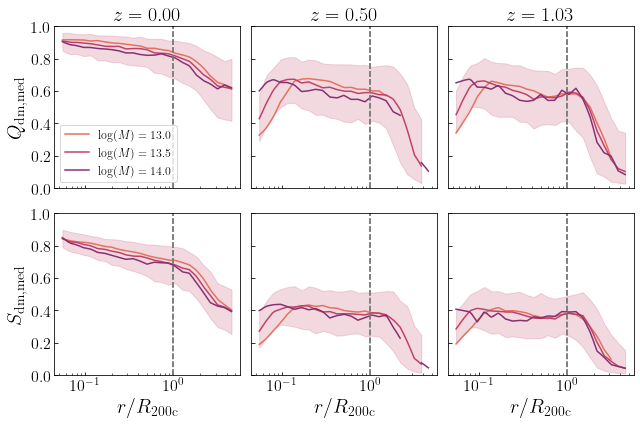

In [19]:
plot_shapes(0, 0, 13.5, islog=False)

In [23]:
def _protected_power(x1, x2):
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        result = np.where(
            (np.abs(x1) < 100) & (np.abs(x2) < 100) & ((x1 >= 0) | (np.floor(x2) == x2)),
            np.power(x1, x2),
            0.
        )
        return np.where(np.isfinite(result), result, 0.)

ppow = make_function(function=_protected_power, name='pow', arity=2)

def _mape_with_penalty(y, y_pred, w):
    """Calculate the mean absolute percentage error with harsh punishment for values outside [0, 1]."""
    # Original MAPE calculation
    diffs = np.abs(np.divide((np.maximum(0.001, y) - np.maximum(0.001, y_pred)),
                             np.maximum(0.001, y)))
    mape = 100. * np.average(diffs, weights=w)

    # Penalty for predictions outside [0, 1]
    penalty = np.sum(y_pred > 0) * 1e6  # Apply a large penalty (1e6) for any value out of bounds

    return mape + penalty

def _mae_with_penalty(y, y_pred, w):
    """Calculate the mean absolute error with harsh punishment for any positive predicted values."""
    # MAE calculation
    diffs = np.abs(y - y_pred)
    mae = np.average(diffs, weights=w)

    # Penalty for predictions with any positive values
    penalty = np.sum(y_pred > 0) * 1e6  # Apply a large penalty (1e6) for any value greater than 0

    return mae + penalty

mape = make_fitness(function=_mape_with_penalty,
                    greater_is_better=False)
mae_with_penalty = make_fitness(function=_mae_with_penalty, greater_is_better=False)

In [24]:
def perform_sr(X_train, y_train):

  valid_indices = ~np.isnan(y_train)
  X_train = X_train[valid_indices]
  y_train = y_train[valid_indices]

  with warnings.catch_warnings():
      warnings.simplefilter("ignore", RuntimeWarning)

      est_gp = SymbolicRegressor(init_depth=(2, 6),
                                population_size=20000,
                                generations=25, stopping_criteria=0.01,
                                p_crossover=0.7, p_subtree_mutation=0.1,
                                p_hoist_mutation=0.05, p_point_mutation=0.1,
                                metric=mae_with_penalty,
                                function_set=('add', 'sub', 'mul', 'div'),
                                max_samples=0.9, verbose=1,
                                parsimony_coefficient=0.0004, random_state=0)
      est_gp.fit(X_train, y_train)

  next_e = sympify(str(est_gp._program), locals=converter)
  next_e = next_e.subs({'X0': 'R', 'X1': 'M', 'X2': 'z'})

  return est_gp, next_e

In [26]:
m_array = np.array((13.0, 13.5, 14.0))
z_array = np.array(("000", "050", "103"))

X_train_rad, y_train_qdm, y_train_sdm = get_train(m_array, z_array, mask=-1.0, islog=True)

datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000


<ipython-input-5-7cfc9333dd9d>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data[j] = f[keys[j]].attrs[att]


datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050
datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103
datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103


In [41]:
est_qdm, qdm_e = perform_sr(X_train_rad, y_train_qdm)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    33.48      4.20597e+09       39         0.130382         0.141176     14.70m
   1    17.02      2.02723e+09       41         0.128628          0.12368     11.07m
   2    12.11      2.11929e+09       39         0.101223         0.104436     11.70m
   3    12.25      2.10648e+09       61        0.0639697        0.0600894     11.98m
   4    21.49      2.07858e+09       71        0.0622225        0.0604296     14.35m
   5    31.33      1.71084e+09       41        0.0617634        0.0618174     15.90m
   6    35.15      1.55394e+09       35        0.0568933        0.0552167     14.95m
   7    37.42       1.6125e+09       73        0.0526833        0.0522328     16.36m
   8    36.61      1.64339e+09       69        0.0513381        0.0520262  

In [28]:
qdm_e

R*z*(R + 0.986)*(-0.445*R*(R + 1.48)/z - 0.282) - 0.187

In [32]:
est_sdm, sdm_e = perform_sr(X_train_rad, y_train_sdm)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    33.48      4.20597e+09        7         0.186572         0.186712     23.54m
   1    16.49      2.05814e+09       15         0.180573         0.165184     15.92m
   2    10.81      2.09248e+09       11         0.147134         0.153605     14.48m
   3     8.98      1.87719e+09       13           0.1227         0.118973     12.54m
   4     7.60      1.84182e+09        9         0.113591         0.110487     12.67m
   5     9.32      2.25001e+09       17        0.0982661        0.0992308     12.31m
   6    10.32        2.232e+09       15        0.0975741         0.104827     12.11m
   7    13.28      1.77066e+09       21         0.079554        0.0821023     11.75m
   8    14.18      1.52459e+09       21        0.0795738        0.0819243  

In [33]:
sdm_e

R**2*z/(z*(R - 0.065) - z) - 0.187*R - 0.187*z - 0.242

datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 13.0
redshift: 000


<ipython-input-5-7cfc9333dd9d>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data[j] = f[keys[j]].attrs[att]


datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 13.0
redshift: 050


<ipython-input-5-7cfc9333dd9d>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data[j] = f[keys[j]].attrs[att]


datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 13.0
redshift: 103


<ipython-input-5-7cfc9333dd9d>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data[j] = f[keys[j]].attrs[att]


datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000


<ipython-input-5-7cfc9333dd9d>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data[j] = f[keys[j]].attrs[att]


datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 13.5
redshift: 000
datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 13.5
redshift: 050
datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 13.5
redshift: 103
datafile: /content/drive/MyDrive/TNG300-1_z0.00_gas.hdf5
halo mass: 14.0
redshift: 000
datafile: /content/drive/MyDrive/TNG300-1_z0.50_gas.hdf5
halo mass: 14.0
redshift: 050
datafile: /content/drive/MyDrive/TNG300-1_z1.03_gas.hdf5
halo mass: 14.0
redshift: 103
filepath: /content/six_plot_shapes_1.png


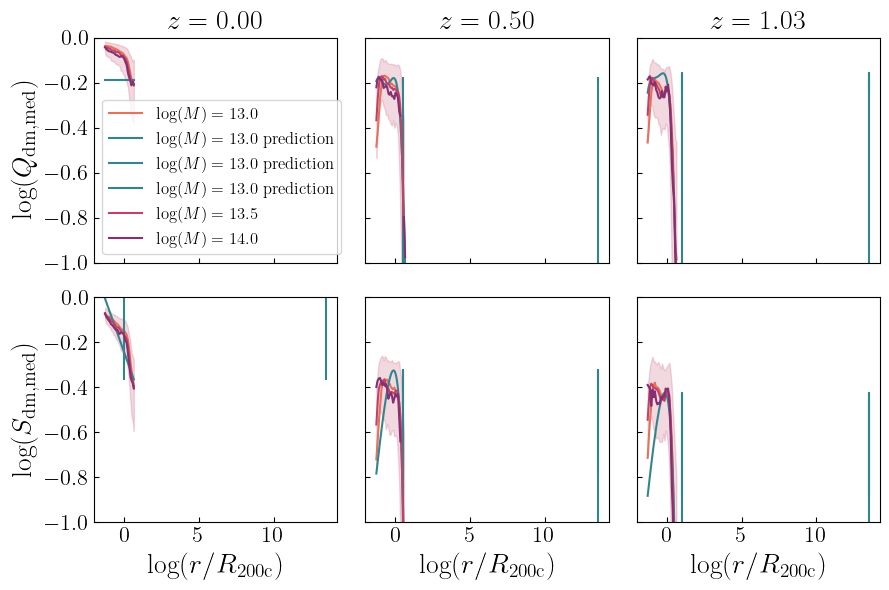

In [34]:
plot_shapes(est_qdm, est_sdm, 13.5, pred_m=13.5, islog=True)